# Auditoria General `<1B`: cobertura

Este notebook ya no construye cobertura pesada en vivo.

Objetivo actual:

- visualizar que datasets tiene cada ticker `<1B`
- ver la ventana PTI de cada ticker
- ver el solape temporal entre `daily`, `ohlcv_1m`, `quotes` y `trades`
- superponer `halts` y `financials` como overlays

Regla operativa:

- el notebook es visor
- el calculo pesado vive en `cel_code/build_lt1b_coverage_artifacts.py`
- no se leen `quotes_current.parquet` ni `trades_current.parquet` full desde aqui


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

AUDIT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria")
CACHE_ROOT = AUDIT_ROOT / "cache_lt1b_coverage"
BUILDER_SCRIPT = AUDIT_ROOT / "cel_code" / "build_lt1b_coverage_artifacts.py"

ARTIFACTS = {
    "manifest": CACHE_ROOT / "manifest.json",
    "build_log": CACHE_ROOT / "build_log.json",
    "exec_summary": CACHE_ROOT / "exec_summary.parquet",
    "dataset_coverage_summary": CACHE_ROOT / "dataset_coverage_summary.parquet",
    "dataset_overlap_summary": CACHE_ROOT / "dataset_overlap_summary.parquet",
    "ticker_coverage_summary": CACHE_ROOT / "ticker_coverage_summary.parquet",
    "ticker_month_coverage": CACHE_ROOT / "ticker_month_coverage.parquet",
    "event_month_overlay": CACHE_ROOT / "event_month_overlay.parquet",
    "case_index_coverage": CACHE_ROOT / "case_index_coverage.parquet",
}

missing = [name for name, path in ARTIFACTS.items() if not path.exists()]
if missing:
    missing_txt = ", ".join(missing)
    raise FileNotFoundError(
        "Faltan artefactos de cobertura en cache_lt1b_coverage. "
        f"Faltan: {missing_txt}. Ejecuta primero: python {BUILDER_SCRIPT}"
    )

manifest = json.loads(ARTIFACTS["manifest"].read_text(encoding="utf-8"))
build_log = json.loads(ARTIFACTS["build_log"].read_text(encoding="utf-8"))

display(Markdown("## Manifest del build"))
display(pd.DataFrame([{
    "build_name": manifest.get("build_name"),
    "build_version": manifest.get("build_version"),
    "built_at_utc": manifest.get("built_at_utc"),
    "output_root": manifest.get("output_root"),
    "lt1b_tickers": manifest.get("row_counts", {}).get("lt1b_tickers"),
    "ticker_month_rows": manifest.get("row_counts", {}).get("ticker_month_rows"),
}]))


## Manifest del build

,build_name,build_version,built_at_utc,output_root,lt1b_tickers,ticker_month_rows
0,lt1b_coverage_artifacts,0.1.0,2026-04-12T14:57:37.222680+00:00,C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\0...,4824,357375


In [2]:
exec_summary = pd.read_parquet(ARTIFACTS["exec_summary"])
dataset_coverage_summary = pd.read_parquet(ARTIFACTS["dataset_coverage_summary"])
dataset_overlap_summary = pd.read_parquet(ARTIFACTS["dataset_overlap_summary"])
ticker_coverage_summary = pd.read_parquet(ARTIFACTS["ticker_coverage_summary"])
case_index_coverage = pd.read_parquet(ARTIFACTS["case_index_coverage"])

display(Markdown("## Resumen ejecutivo"))
display(exec_summary.T.rename(columns={0: "value"}))

display(Markdown("## Cobertura global por dataset"))
display(dataset_coverage_summary)


## Resumen ejecutivo

,value
universe_name,lt1b_active_inactive
as_of_date,2026-04-12 00:00:00
lt1b_tickers_total,4824
pti_min_date,2005-01-01 00:00:00
pti_max_date,2026-03-09 00:00:00
pti_month_rows_total,357375
tickers_with_daily,4824
tickers_with_ohlcv_1m,4824
tickers_with_quotes,4822
tickers_with_trades,4823


## Cobertura global por dataset

,dataset,dataset_kind,tickers_with_data,tickers_without_data,months_with_data,obs_min_date,obs_max_date,coverage_vs_universe_pct
0,daily,dense_market,4824,0,356983,2005-01-01,2026-03-01,100.0000
1,ohlcv_1m,dense_market,4824,0,356981,2005-01-01,2026-03-01,100.0000
2,quotes,dense_market,4822,2,334948,2005-01-01,2026-03-01,99.9585
3,trades,dense_market,4823,1,335063,2005-01-01,2026-03-01,99.9793
4,halts,event,3730,1094,14175,2005-01-01,2026-03-01,77.3217
5,balance,fundamental,4813,11,82673,2010-04-01,2026-03-01,99.7720
6,cash_flow,fundamental,4794,30,74870,2010-06-01,2026-03-01,99.3781
7,income,fundamental,4815,9,75218,2010-06-01,2026-03-01,99.8134
8,ratio,fundamental,2042,2782,2042,2026-02-01,2026-03-01,42.3300


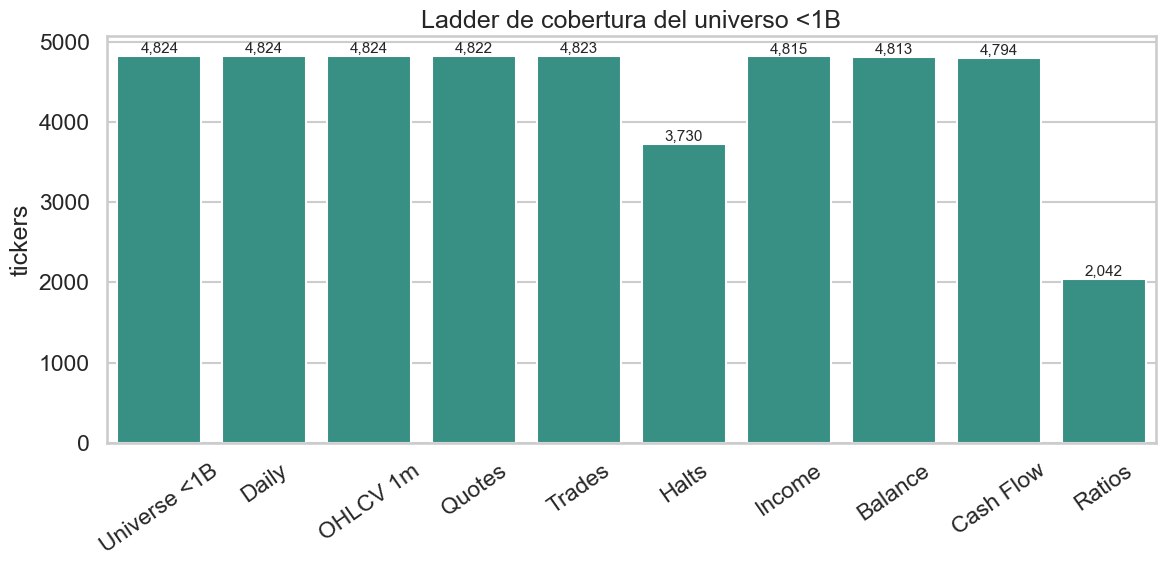

In [3]:
ladder_df = pd.DataFrame([
    {"label": "Universe <1B", "tickers": int(exec_summary.loc[0, "lt1b_tickers_total"])} ,
    {"label": "Daily", "tickers": int(exec_summary.loc[0, "tickers_with_daily"])} ,
    {"label": "OHLCV 1m", "tickers": int(exec_summary.loc[0, "tickers_with_ohlcv_1m"])} ,
    {"label": "Quotes", "tickers": int(exec_summary.loc[0, "tickers_with_quotes"])} ,
    {"label": "Trades", "tickers": int(exec_summary.loc[0, "tickers_with_trades"])} ,
    {"label": "Halts", "tickers": int(exec_summary.loc[0, "tickers_with_halts"])} ,
    {"label": "Income", "tickers": int(exec_summary.loc[0, "tickers_with_income"])} ,
    {"label": "Balance", "tickers": int(exec_summary.loc[0, "tickers_with_balance"])} ,
    {"label": "Cash Flow", "tickers": int(exec_summary.loc[0, "tickers_with_cash_flow"])} ,
    {"label": "Ratios", "tickers": int(exec_summary.loc[0, "tickers_with_ratio"])} ,
])

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=ladder_df, x="label", y="tickers", color="#2a9d8f")
ax.set_title("Ladder de cobertura del universo <1B")
ax.set_xlabel("")
ax.set_ylabel("tickers")
ax.tick_params(axis="x", rotation=35)
for patch, value in zip(ax.patches, ladder_df["tickers"]):
    ax.text(patch.get_x() + patch.get_width() / 2, value, f"{value:,}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()


## Overlaps entre datasets

,combo_key,combo_label,tickers_count,pct_universe
0,daily&ohlcv_1m,daily&ohlcv_1m,4824,100.0000
1,daily&trades,daily&trades,4823,99.9793
2,daily&ohlcv_1m&quotes&trades,daily&ohlcv_1m&quotes&trades,4822,99.9585
3,daily&quotes,daily&quotes,4822,99.9585
4,quotes&trades,quotes&trades,4822,99.9585
5,all_market_data+financials_any,all_market_data+financials_any,4814,99.7927
6,all_market_data+income,all_market_data+income,4814,99.7927


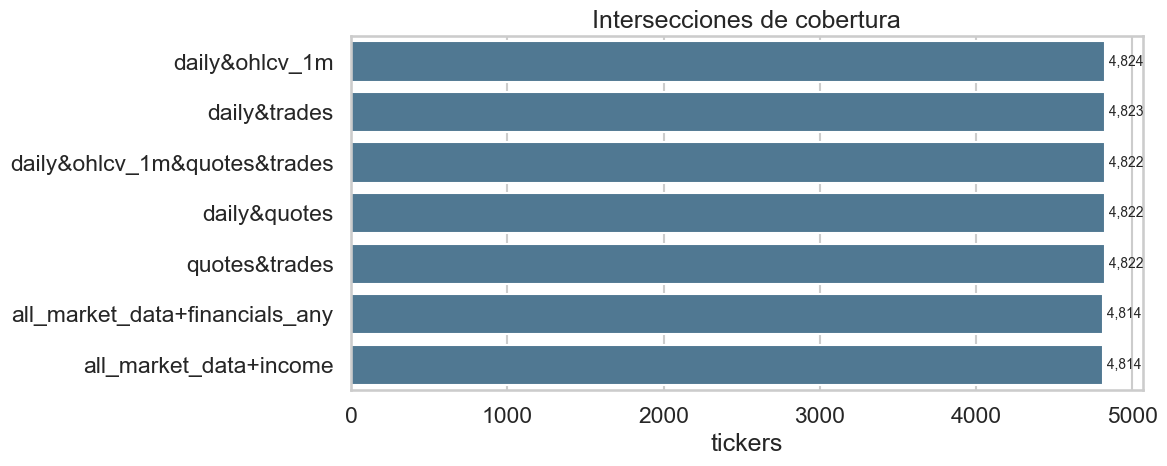

In [4]:
display(Markdown("## Overlaps entre datasets"))
display(dataset_overlap_summary)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=dataset_overlap_summary, y="combo_label", x="tickers_count", color="#457b9d")
ax.set_title("Intersecciones de cobertura")
ax.set_xlabel("tickers")
ax.set_ylabel("")
for patch, value in zip(ax.patches, dataset_overlap_summary["tickers_count"]):
    ax.text(value, patch.get_y() + patch.get_height() / 2, f" {value:,}", va="center", fontsize=10)
plt.tight_layout()


In [5]:
bucket_counts = (
    ticker_coverage_summary["coverage_bucket"]
    .value_counts(dropna=False)
    .rename_axis("coverage_bucket")
    .reset_index(name="tickers")
)

display(Markdown("## Buckets de cobertura por ticker"))
display(bucket_counts)

display(Markdown("## Tabla principal por ticker"))
cols = [
    "ticker", "classification_1b", "pti_start", "pti_end",
    "daily_coverage_pct", "ohlcv_1m_coverage_pct", "quotes_coverage_pct", "trades_coverage_pct",
    "halts_events_total", "income_events_total", "balance_events_total", "cash_flow_events_total", "ratio_points_total",
    "coverage_bucket", "top_gap_dataset",
]
display(ticker_coverage_summary[cols].sort_values(["coverage_bucket", "ticker"]).head(100))


## Buckets de cobertura por ticker

,coverage_bucket,tickers
0,all_market_data,4822
1,missing_quotes,1
2,partial_market_data,1


## Tabla principal por ticker

,ticker,classification_1b,pti_start,pti_end,daily_coverage_pct,ohlcv_1m_coverage_pct,quotes_coverage_pct,trades_coverage_pct,halts_events_total,income_events_total,balance_events_total,cash_flow_events_total,ratio_points_total,coverage_bucket,top_gap_dataset
0,AACT,inactive_died_lt_1b,2023-06-12,2025-09-24,100.0,100.0,100.000,100.000,0,16,9,13,0,all_market_data,daily
1,AAGR,inactive_died_lt_1b,2023-12-07,2024-09-25,100.0,100.0,100.000,100.000,6,5,3,5,0,all_market_data,daily
2,AAIC,inactive_died_lt_1b,2020-10-26,2023-12-14,100.0,100.0,100.000,100.000,0,27,14,27,0,all_market_data,daily
3,AAMC,inactive_died_lt_1b,2014-08-15,2024-09-16,100.0,100.0,97.541,97.541,20,98,52,98,0,all_market_data,quotes
4,AAME,active_lt_1b_last_classifiable,2016-10-25,2026-03-09,100.0,100.0,100.000,100.000,19,86,44,86,1,all_market_data,daily
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,AERI,inactive_died_lt_1b,2016-10-25,2022-11-21,100.0,100.0,100.000,100.000,3,68,33,68,0,all_market_data,daily
96,AERT,active_lt_1b_last_classifiable,2023-11-08,2026-03-09,100.0,100.0,100.000,100.000,8,19,11,19,1,all_market_data,daily
97,AETI,inactive_died_lt_1b,2016-10-25,2019-07-28,100.0,100.0,100.000,100.000,13,25,14,25,0,all_market_data,daily
98,AEVA,active_lt_1b_last_classifiable,2021-03-15,2026-03-09,100.0,100.0,100.000,100.000,1,42,23,42,1,all_market_data,daily


In [6]:
# Si quieres fijar un ticker concreto, cambia este valor.
SELECTED_TICKER = None

if SELECTED_TICKER is None:
    selected_row = case_index_coverage.sort_values(["rank_score", "ticker"], ascending=[False, True]).iloc[0]
    SELECTED_TICKER = str(selected_row["ticker"])

selected_ticker = str(SELECTED_TICKER).strip().upper()
selected_summary = ticker_coverage_summary.loc[ticker_coverage_summary["ticker"].astype(str).str.upper() == selected_ticker].copy()
if selected_summary.empty:
    raise ValueError(f"Ticker no encontrado en ticker_coverage_summary: {selected_ticker}")

display(Markdown(f"## Ticker seleccionado: `{selected_ticker}`"))
display(selected_summary.T.rename(columns={selected_summary.index[0]: "value"}))


## Ticker seleccionado: `ETS`

,value
ticker,ETS
pti_start,2005-01-01 00:00:00
pti_end,2026-03-09 00:00:00
classification_1b,active_lt_1b_last_classifiable
classification_reason_1b,active_and_market_cap_t_lt_1b
pti_months,255
daily_has_any,True
daily_obs_start,2005-01-01 00:00:00
daily_obs_end,2026-03-01 00:00:00
daily_months_present,255


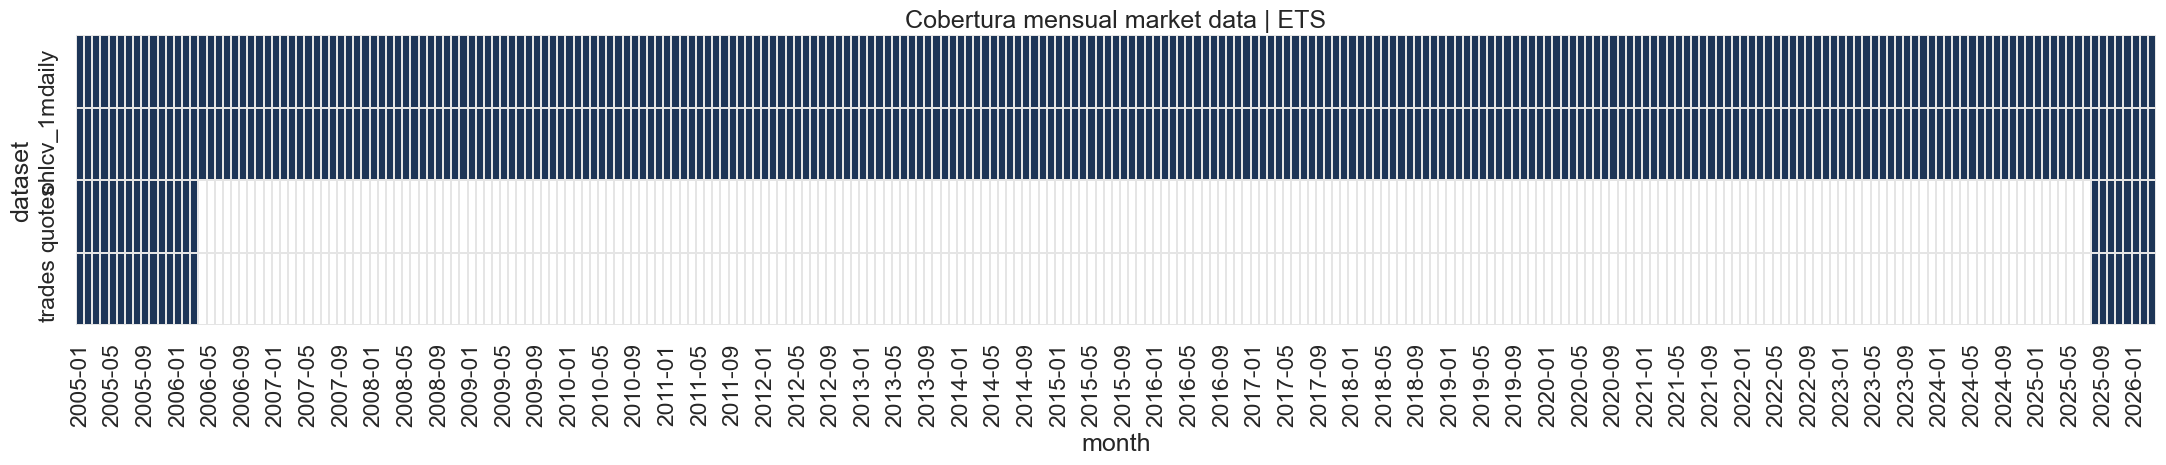

In [7]:
ticker_month_coverage = pd.read_parquet(ARTIFACTS["ticker_month_coverage"])
event_month_overlay = pd.read_parquet(ARTIFACTS["event_month_overlay"])

ticker_month = ticker_month_coverage.loc[ticker_month_coverage["ticker"].astype(str).str.upper() == selected_ticker].copy()
ticker_events = event_month_overlay.loc[event_month_overlay["ticker"].astype(str).str.upper() == selected_ticker].copy()
ticker_view = ticker_month.merge(ticker_events, on=["ticker", "month"], how="left")

for col in ["has_halts_event", "has_income_statement", "has_balance_sheet", "has_cash_flow_statement", "has_ratio"]:
    if col in ticker_view.columns:
        ticker_view[col] = ticker_view[col].astype("boolean").fillna(False).astype(bool)
for col in ["halts_events_count", "income_events_count", "balance_events_count", "cash_flow_events_count", "ratio_points_count"]:
    if col in ticker_view.columns:
        ticker_view[col] = pd.to_numeric(ticker_view[col], errors="coerce").fillna(0).astype(int)

market_heat = ticker_view[["month", "has_daily", "has_ohlcv_1m", "has_quotes", "has_trades"]].copy()
market_heat = market_heat.rename(columns={
    "has_daily": "daily",
    "has_ohlcv_1m": "ohlcv_1m",
    "has_quotes": "quotes",
    "has_trades": "trades",
})
market_heat["month"] = pd.to_datetime(market_heat["month"], errors="coerce").dt.strftime("%Y-%m")
market_heat = market_heat.set_index("month").T.astype(int)

plt.figure(figsize=(22, 5))
ax = sns.heatmap(
    market_heat,
    cmap=sns.color_palette(["#ffffff", "#1d3557"], as_cmap=True),
    cbar=False,
    linewidths=0.2,
    linecolor="#e5e5e5",
)
ax.set_title(f"Cobertura mensual market data | {selected_ticker}")
ax.set_xlabel("month")
ax.set_ylabel("dataset")
plt.tight_layout()


## Detalle mensual del ticker

,ticker,month,has_daily,has_ohlcv_1m,has_quotes,has_trades,has_halts_event,halts_events_count,has_income_statement,income_events_count,has_balance_sheet,balance_events_count,has_cash_flow_statement,cash_flow_events_count,has_ratio,ratio_points_count
135,ETS,2016-04-01,True,True,False,False,False,0,False,0,False,0,False,0,False,0
136,ETS,2016-05-01,True,True,False,False,False,0,False,0,False,0,False,0,False,0
137,ETS,2016-06-01,True,True,False,False,False,0,False,0,False,0,False,0,False,0
138,ETS,2016-07-01,True,True,False,False,False,0,False,0,False,0,False,0,False,0
139,ETS,2016-08-01,True,True,False,False,False,0,False,0,False,0,False,0,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,ETS,2025-11-01,True,True,True,True,False,0,False,0,False,0,False,0,False,0
251,ETS,2025-12-01,True,True,True,True,False,0,False,0,False,0,False,0,False,0
252,ETS,2026-01-01,True,True,True,True,False,0,False,0,False,0,False,0,False,0
253,ETS,2026-02-01,True,True,True,True,False,0,False,0,False,0,False,0,False,0


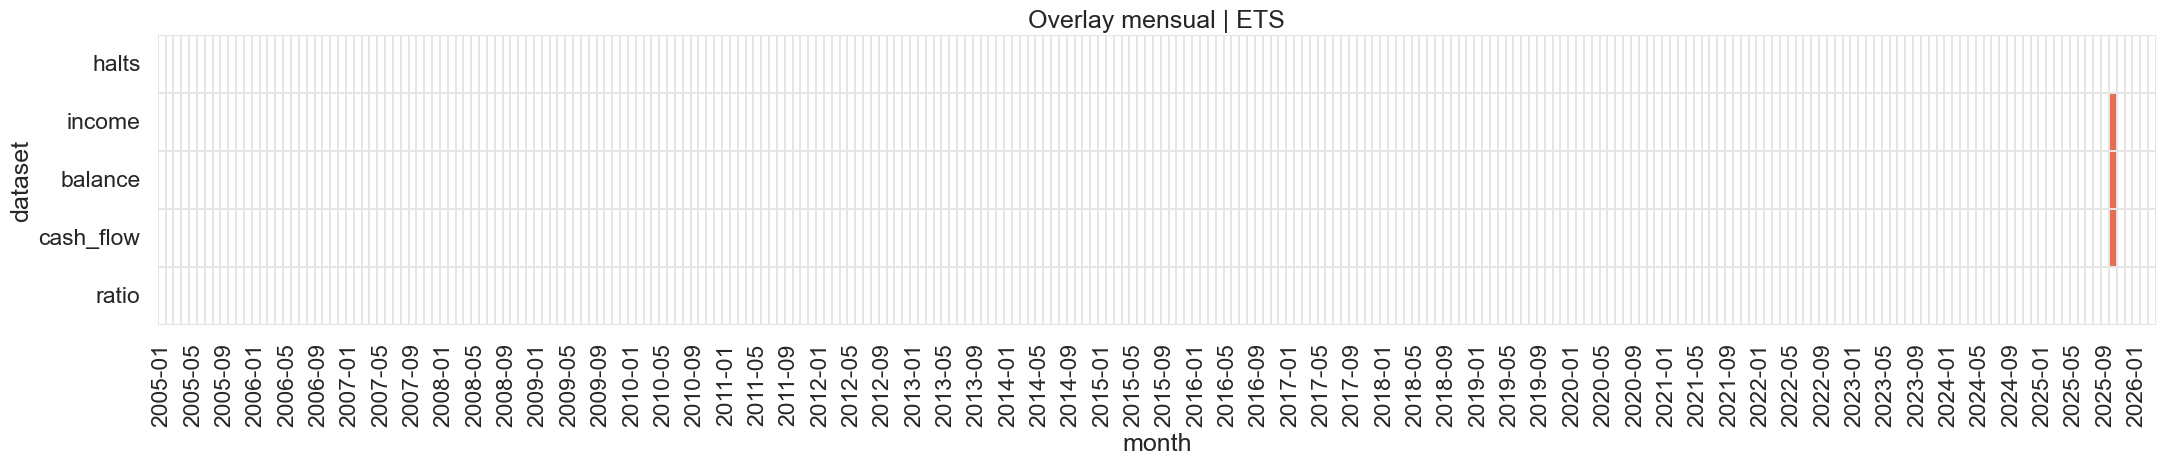

In [8]:
overlay_cols = [
    "has_halts_event",
    "has_income_statement",
    "has_balance_sheet",
    "has_cash_flow_statement",
    "has_ratio",
]
overlay_heat = ticker_view[["month", *overlay_cols]].copy()
overlay_heat = overlay_heat.rename(columns={
    "has_halts_event": "halts",
    "has_income_statement": "income",
    "has_balance_sheet": "balance",
    "has_cash_flow_statement": "cash_flow",
    "has_ratio": "ratio",
})
overlay_heat["month"] = pd.to_datetime(overlay_heat["month"], errors="coerce").dt.strftime("%Y-%m")
overlay_heat = overlay_heat.set_index("month").T.astype(int)

plt.figure(figsize=(22, 5))
ax = sns.heatmap(
    overlay_heat,
    cmap=sns.color_palette(["#ffffff", "#e76f51"], as_cmap=True),
    cbar=False,
    linewidths=0.2,
    linecolor="#e5e5e5",
)
ax.set_title(f"Overlay mensual | {selected_ticker}")
ax.set_xlabel("month")
ax.set_ylabel("dataset")
plt.tight_layout()

display(Markdown("## Detalle mensual del ticker"))
detail_cols = [
    "ticker", "month", "has_daily", "has_ohlcv_1m", "has_quotes", "has_trades",
    "has_halts_event", "halts_events_count",
    "has_income_statement", "income_events_count",
    "has_balance_sheet", "balance_events_count",
    "has_cash_flow_statement", "cash_flow_events_count",
    "has_ratio", "ratio_points_count",
]
display(ticker_view[detail_cols].sort_values("month").tail(120))
